Fresh care satellite processing:

In [1]:
import xarray as xr
import numpy as np
import os
import matplotlib.pyplot as plt
import cmocean.cm as cm
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import dask.array as da
import glob
import tqdm
from datetime import datetime

In [49]:
out_path = '../data_for_lstm/var_depths_data_for_LSTM_A2.nc'

In [8]:
in_situ_dir = '../data_for_lstm/'
in_situ_file = 'var_depths_data_for_LSTM_A1.nc'
in_situ_path = os.path.join(in_situ_dir, in_situ_file)

SST_dir = '/home/nicolas/SACO/FRESH-CARE/Data_satellite/SST/data/'
SST_file = '*/*/*.nc'
SST_path = os.path.join(SST_dir, SST_file)

SSS_dir = '/home/nicolas/SACO/FRESH-CARE/Data_satellite/SSS/sss_cci_v55/non_regridded_filled_wg/'
SSS_file = '*.nc'
SSS_path = os.path.join(SSS_dir, SSS_file)

-------------------------------
-------------------------------
OPEN IN SITU DATA

In [9]:
ds_insitu = xr.open_dataset(in_situ_path)
ds_insitu = ds_insitu.compute()  # Fixed: assign the computed result
print(f'In-situ dataset loaded with shape: {ds_insitu.sizes}')

In-situ dataset loaded with shape: Frozen({'profile': 187276, 'depth': 102})


In [10]:
print(f"In situ dataset size: {ds_insitu.nbytes / 1e9:.2f} GB")

In situ dataset size: 0.93 GB


---
---
OPEN SATELITE DATA (salinity is filled with glorys under ice)

just an example for sst

In [11]:
ds_SST = xr.open_mfdataset(SST_dir + '/2015/10/*.nc')
ds_SST

<xarray.Dataset> Size: 3GB
Dimensions:             (time: 31, latitude: 800, longitude: 7200)
Coordinates:
  * time                (time) datetime64[ns] 248B 2015-10-01 ... 2015-10-31
  * latitude            (latitude) float32 3kB 50.03 50.08 50.13 ... 89.93 89.98
  * longitude           (longitude) float32 29kB -180.0 -179.9 ... 179.9 180.0
Data variables:
    analysed_sst        (time, latitude, longitude) float64 1GB dask.array<chunksize=(1, 25, 225), meta=np.ndarray>
    analysis_error_sst  (time, latitude, longitude) float64 1GB dask.array<chunksize=(1, 25, 225), meta=np.ndarray>
Attributes:
    references:                Høyer, J. L. and She, J., Optimal interpolatio...
    Conventions:               CF-1.4, Unidata Observation Dataset v1.0
    source:                    ESA SST CCI v3.0 and C3S v3.0 L3U, AASTIv2 IST...
    history:                   Version 1.0
    comment:                   IN NO EVENT SHALL DMI OR ITS REPRESENTATIVES B...
    title:                     Global Sea and Ice Surface Temperature, L4, 5k...
    institution:               Danish Meteorological Institute, DMI
    copernicusmarine_version:  2.2.3

In [12]:
ds_SST.close()
del ds_SST

In [13]:
ds_SSS = xr.open_mfdataset(SSS_path)
ds_SSS

<xarray.Dataset> Size: 5GB
Dimensions:             (time: 5097, y_ease: 392, x_ease: 392)
Coordinates:
  * time                (time) datetime64[ns] 41kB 2010-01-09 ... 2023-12-30
  * y_ease              (y_ease) float64 3kB -4.9e+06 -4.875e+06 ... 4.875e+06
  * x_ease              (x_ease) float64 3kB -4.9e+06 -4.875e+06 ... 4.875e+06
    lat                 (y_ease, x_ease) float32 615kB dask.array<chunksize=(392, 392), meta=np.ndarray>
    lon                 (y_ease, x_ease) float32 615kB dask.array<chunksize=(392, 392), meta=np.ndarray>
Data variables:
    sss                 (time, y_ease, x_ease) float32 3GB dask.array<chunksize=(1, 392, 392), meta=np.ndarray>
    fill_mask           (time, y_ease, x_ease) bool 783MB dask.array<chunksize=(1, 392, 392), meta=np.ndarray>
    fill_mask_edges     (time, y_ease, x_ease) bool 783MB dask.array<chunksize=(1, 392, 392), meta=np.ndarray>
    original_data_mask  (time, y_ease, x_ease) bool 783MB dask.array<chunksize=(1, 392, 392), meta=np.ndarray>
Attributes: (12/49)
    CDI:                       Climate Data Interface version 2.3.0 (https://...
    Conventions:               CF-1.8
    source:                    SMOS CCI L2OS reprocessing from DPGS L1Cv7, SM...
    institution:               ACRI-ST,LOCEAN
    title:                     ESA CCI SSS v5.5 on EASE2-N 25 km grid — gap-f...
    history:                   2026-04-10: NaN gaps filled with GLORYS12 (CME...
    ...                        ...
    CDO:                       Climate Data Operators version 2.3.0 (https://...
    grid_mapping_name:         lambert_azimuthal_equal_area
    proj4_string:              +proj=laea +lat_0=90 +lon_0=0 +x_0=0 +y_0=0 +d...
    GLORYS_source:             CMEMS GLOBAL_MULTIYEAR_PHY_001_030, daily, 1/1...
    GLORYS_fill_method:        Nearest-neighbour: for each EASE2 cell, the ge...
    y_axis_note:               y_ease axis is flipped relative to the ESA CCI...

In [14]:
ds_SSS.close()
del ds_SSS

---
---
### Match up: push nearest surface data into in situ coordinates

In [15]:
# Check if in-situ time is sorted (monotonically increasing)
is_sorted = np.all(np.diff(ds_insitu['TIME'].values) >= np.timedelta64(0, 'D'))
print(f"In-situ time coordinate is sorted: {is_sorted}")

In-situ time coordinate is sorted: True


In [16]:
ds_insitu['TIME'].sizes

Frozen({'profile': 187276})

---
---
#### interpolate SST month by month, this can take about 1-2h

In [17]:
# Process SST interpolation with boundary files to avoid boundary NaNs
# Initialize result array with NaNs
nearest_SST = xr.DataArray(
    np.full(len(ds_insitu['TIME']), np.nan),
    dims=['profile'],
    coords={'profile': ds_insitu['profile']},
)

# Get year-month combinations from in-situ data
insitu_times = pd.to_datetime(ds_insitu['TIME'].values)
unique_months = insitu_times.to_period('M').unique()

print(f"Processing {len(unique_months)} unique months from in-situ data")
print("Using month + boundary files (last day of prev month + first day of next month)")

# Process each month with boundary files
for period in tqdm.tqdm(unique_months, desc="Processing SST by month"):
    year = period.year
    month = period.month
    
    # Determine previous and next months
    prev_period = period - 1
    next_period = period + 1
    
    # Build list of files to load
    files_to_load = []
    
    # Add last file from previous month (boundary file)
    prev_dir = os.path.join(SST_dir, f"{prev_period.year:04d}/{prev_period.month:02d}")
    if os.path.exists(prev_dir):
        prev_files = sorted(glob.glob(os.path.join(prev_dir, "*.nc")))
        if len(prev_files) > 0:
            files_to_load.append(prev_files[-1])  # Last file of previous month
    
    # Add all files from current month
    curr_dir = os.path.join(SST_dir, f"{year:04d}/{month:02d}")
    curr_files = sorted(glob.glob(os.path.join(curr_dir, "*.nc")))
    if len(curr_files) > 0:
        files_to_load.extend(curr_files)
    else:
        print(f"  No SST files found for {year}-{month:02d}, skipping...")
        continue
    
    # Add first file from next month (boundary file)
    next_dir = os.path.join(SST_dir, f"{next_period.year:04d}/{next_period.month:02d}")
    if os.path.exists(next_dir):
        next_files = sorted(glob.glob(os.path.join(next_dir, "*.nc")))
        if len(next_files) > 0:
            files_to_load.append(next_files[0])  # First file of next month
    
    # Open current month + boundary files
    ds_SST_window = xr.open_mfdataset(files_to_load)
    
    # Find in-situ profiles from the current month
    month_mask = (insitu_times.year == year) & (insitu_times.month == month)
    month_indices = np.where(month_mask)[0]
    
    if len(month_indices) == 0:
        ds_SST_window.close()
        continue
    
    # Interpolate for this month's profiles
    month_result = ds_SST_window['analysed_sst'].interp(
        coords={
            'time': ds_insitu['TIME'].isel(profile=month_indices),
            'latitude': ds_insitu['LATITUDE'].isel(profile=month_indices),
            'longitude': ds_insitu['LONGITUDE'].isel(profile=month_indices)
        },
        method='nearest'
    ).compute()
    
    # Fill the result array converting to Celsius
    nearest_SST.values[month_indices] = month_result.values - 273.15
    
    # Close the window dataset to free memory
    ds_SST_window.close()

# Summary
n_nans = np.sum(np.isnan(nearest_SST.values))
print(f"\nSST interpolation complete!")
print(f"Total profiles: {len(nearest_SST)}")
print(f"NaN count: {n_nans}")
print(f"NaN fraction: {n_nans / len(nearest_SST):.2%}")

Processing 132 unique months from in-situ data
Using month + boundary files (last day of prev month + first day of next month)


Processing SST by month:   0%|          | 0/132 [00:00<?, ?it/s]

Processing SST by month: 100%|██████████| 132/132 [36:49<00:00, 16.74s/it]


SST interpolation complete!
Total profiles: 187276
NaN count: 1392
NaN fraction: 0.74%


Add the variable attrs and make a safety save

In [18]:
# Add attributes
nearest_SST.attrs = {
    'long_name': 'Nearest Satellite SST',
    'units': 'degree_Celsius',
    'standard_name': 'sea_surface_temperature',
    'description': 'SST values interpolated to in situ profile locations and times using nearest neighbor method.'
}


In [19]:
# Safety save with SST only
safety_path = '../data_for_lstm/aux_saves/A2_nearest_SST_intermediate.nc'
os.makedirs(os.path.dirname(safety_path), exist_ok=True)
print(f"Saving intermediate dataset with SST to {safety_path}...")

# Create a simple dataset with just SST
ds_sst_only = xr.Dataset({'SST': nearest_SST})
ds_sst_only.to_netcdf(safety_path)

print(f"Safety save complete! File saved at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Saving intermediate dataset with SST to ../data_for_lstm/aux_saves/A2_nearest_SST_intermediate.nc...
Safety save complete! File saved at: 2026-04-11 16:15:52


In [20]:
# Add SST to the dataset
ds_insitu['SST'] = nearest_SST

---
#### Now process SSS (much quicker) - we add 1pxl tolerance

In [31]:

from scipy.ndimage import distance_transform_edt

# Process SSS interpolation with 3-year overlapping windows to avoid boundary NaNs
# Initialize result array with NaNs
nearest_SSS = xr.DataArray(
    np.full(len(ds_insitu['TIME']), np.nan),
    dims=['profile'],
    coords={'profile': ds_insitu['profile']},
)

# Get unique years from in-situ data
insitu_times = pd.to_datetime(ds_insitu['TIME'].values)
unique_years = insitu_times.year.unique()

print(f"Processing {len(unique_years)} unique years from in-situ data")
print("Using 3-year overlapping windows (prev + current + next) to handle boundary interpolation")
print("1-pixel fallback enabled for profiles landing on NaN pixels")

# Process each year with ±1 year buffer
for year in tqdm.tqdm(unique_years, desc="Processing SSS by year"):
    
    # Determine previous and next years
    prev_year = year - 1
    next_year = year + 1
    
    # Build list of files to load (prev, current, next years)
    files_to_load = []
    for y in [prev_year, year, next_year]:
        path_pattern = os.path.join(SSS_dir, f'*{y}*.nc')
        files = glob.glob(path_pattern)
        if len(files) > 0:
            files_to_load.extend(files)  # Add actual file paths, not pattern
    
    if len(files_to_load) == 0:
        print(f"  No SSS files found for {year} or adjacent years, skipping...")
        continue
    
    # Open 3-year window of SSS data
    ds_SSS_window = xr.open_mfdataset(files_to_load)
    
    # Find in-situ profiles from the current year
    year_mask = (insitu_times.year == year)
    year_indices = np.where(year_mask)[0]
    
    if len(year_indices) == 0:
        ds_SSS_window.close()
        continue
    
    # Interpolate for this year's profiles using the 3-year window
    year_result = ds_SSS_window['sss'].interp(
        coords={
            'time': ds_insitu['TIME'].isel(profile=year_indices),
            'y_ease': ds_insitu['Y_EASE'].isel(profile=year_indices),
            'x_ease': ds_insitu['X_EASE'].isel(profile=year_indices)
        },
        method='nearest'
    ).compute()
    
    # Fill the result array
    nearest_SSS.values[year_indices] = year_result.values

    # --- 1-pixel fallback for profiles that landed on a NaN SSS pixel ---
    nan_in_result = np.isnan(year_result.values)
    if nan_in_result.any():
        nan_year_indices = year_indices[nan_in_result]

        # Load the raw SSS array and expand NaN pixels by 1 pixel using distance transform
        sss_raw = ds_SSS_window['sss'].values  # shape: (time, y_ease, x_ease)
        sss_filled = np.empty_like(sss_raw)

        for t in range(sss_raw.shape[0]):
            layer = sss_raw[t]
            nan_mask_2d = np.isnan(layer)
            if nan_mask_2d.any():
                dist, indices = distance_transform_edt(
                    nan_mask_2d, return_distances=True, return_indices=True
                )
                filled = layer.copy()
                fill_mask = nan_mask_2d & (dist <= 1.0)  # only 1-pixel border
                filled[fill_mask] = layer[tuple(idx[fill_mask] for idx in indices)]
                sss_filled[t] = filled
            else:
                sss_filled[t] = layer

        # Build a new DataArray with the expanded field
        sss_filled_da = xr.DataArray(
            sss_filled,
            dims=ds_SSS_window['sss'].dims,
            coords=ds_SSS_window['sss'].coords
        )

        # Re-interpolate only for the failed profiles
        fallback_result = sss_filled_da.interp(
            coords={
                'time': ds_insitu['TIME'].isel(profile=nan_year_indices),
                'y_ease': ds_insitu['Y_EASE'].isel(profile=nan_year_indices),
                'x_ease': ds_insitu['X_EASE'].isel(profile=nan_year_indices)
            },
            method='nearest'
        ).compute()

        nearest_SSS.values[nan_year_indices] = fallback_result.values
        n_recovered = (~np.isnan(fallback_result.values)).sum()
        print(f"  Year {year}: 1-px fallback recovered {n_recovered}/{nan_in_result.sum()} NaN profiles")
    # --- end fallback ---

    # Close the window dataset to free memory
    ds_SSS_window.close()

# Summary
n_nans = np.sum(np.isnan(nearest_SSS.values))
print(f"\nSSS interpolation complete!")
print(f"Total profiles: {len(nearest_SSS)}")
print(f"NaN count: {n_nans}")
print(f"NaN fraction: {n_nans / len(nearest_SSS):.2%}")


Processing 11 unique years from in-situ data
Using 3-year overlapping windows (prev + current + next) to handle boundary interpolation
1-pixel fallback enabled for profiles landing on NaN pixels


Processing SSS by year:   9%|▉         | 1/11 [00:10<01:46, 10.70s/it]

  Year 2011: 1-px fallback recovered 1566/1940 NaN profiles


Processing SSS by year:  18%|█▊        | 2/11 [00:20<01:29,  9.94s/it]

  Year 2012: 1-px fallback recovered 1171/1415 NaN profiles


...

  Year 2019: 1-px fallback recovered 533/679 NaN profiles


Processing SSS by year:  91%|█████████ | 10/11 [01:25<00:08,  8.24s/it]

  Year 2020: 1-px fallback recovered 336/582 NaN profiles


Processing SSS by year: 100%|██████████| 11/11 [01:34<00:00,  8.55s/it]

  Year 2021: 1-px fallback recovered 436/799 NaN profiles

SSS interpolation complete!
Total profiles: 187276
NaN count: 2667
NaN fraction: 1.42%


Add attrs and add the variable to the dataset

In [32]:
# Add attributes
nearest_SSS.attrs = {
    'long_name': 'Nearest Satellite SSS',
    'units': '1',
    'standard_name': 'sea_surface_salinity',
    'description': 'SSS values interpolated to in situ profile locations and times using nearest neighbor method.'
}

ds_insitu['SSS'] = nearest_SSS


---
---
### Fix SST longitude wraparound issues at ±180° boundary

In [24]:
# Fix SST NaNs near longitude boundaries (±180° wraparound issue)
# Identify NaN profiles that might be affected by dateline crossing
SST_nan_mask = np.isnan(nearest_SST.values)
nan_indices_sst = np.where(SST_nan_mask)[0]

if len(nan_indices_sst) > 0:
    # Check which NaN profiles are near the dateline (lon > 170 or lon < -170)
    nan_lons = ds_insitu['LONGITUDE'].values[nan_indices_sst]
    dateline_mask = (nan_lons > 177) | (nan_lons < -177)
    dateline_indices = nan_indices_sst[dateline_mask]
    
    print(f"SST NaN profiles: {len(nan_indices_sst)}")
    print(f"SST NaN profiles near dateline (|lon| > 177): {len(dateline_indices)}")
    
    if len(dateline_indices) > 0:
        # Fix by normalizing longitudes to 0-360 range
        # Process month by month to avoid RAM issues
        nearest_SST_fixed = nearest_SST.values.copy()
        
        insitu_times = pd.to_datetime(ds_insitu['TIME'].values)
        dateline_times = insitu_times[dateline_indices]
        unique_months = dateline_times.to_period('M').unique()
        
        print(f"Processing {len(unique_months)} months for dateline profiles...")
        
        for period in tqdm.tqdm(unique_months, desc="Fixing SST dateline"):
            year = period.year
            month = period.month
            
            # Find dateline profiles for this month
            month_mask = (dateline_times.year == year) & (dateline_times.month == month)
            month_dateline_indices = dateline_indices[month_mask]
            
            if len(month_dateline_indices) == 0:
                continue
            
            # Load month files with boundaries
            prev_period = period - 1
            next_period = period + 1
            files_to_load = []
            
            prev_dir = os.path.join(SST_dir, f"{prev_period.year:04d}/{prev_period.month:02d}")
            if os.path.exists(prev_dir):
                prev_files = sorted(glob.glob(os.path.join(prev_dir, "*.nc")))
                if len(prev_files) > 0:
                    files_to_load.append(prev_files[-1])
            
            curr_dir = os.path.join(SST_dir, f"{year:04d}/{month:02d}")
            curr_files = sorted(glob.glob(os.path.join(curr_dir, "*.nc")))
            if len(curr_files) > 0:
                files_to_load.extend(curr_files)
            else:
                continue
            
            next_dir = os.path.join(SST_dir, f"{next_period.year:04d}/{next_period.month:02d}")
            if os.path.exists(next_dir):
                next_files = sorted(glob.glob(os.path.join(next_dir, "*.nc")))
                if len(next_files) > 0:
                    files_to_load.append(next_files[0])
            
            ds_SST_window = xr.open_mfdataset(files_to_load)
            
            # Normalize SST dataset longitude to 0-360
            sst_lon = ds_SST_window['longitude'].values
            
            sst_lon_normalized = np.where(sst_lon < 0, sst_lon + 360, sst_lon)
            ds_SST_norm = ds_SST_window.assign_coords(longitude=sst_lon_normalized)
            
            # Normalize in-situ longitudes to 0-360 for these profiles
            # Keep as xarray DataArray to preserve coordinate alignment
            insitu_lon_orig = ds_insitu['LONGITUDE'].isel(profile=month_dateline_indices)
            insitu_lon_norm = xr.where(insitu_lon_orig < 0, insitu_lon_orig + 360, insitu_lon_orig)
            
            # Re-interpolate
            month_result = ds_SST_norm['analysed_sst'].interp(
                coords={
                    'time': ds_insitu['TIME'].isel(profile=month_dateline_indices),
                    'latitude': ds_insitu['LATITUDE'].isel(profile=month_dateline_indices),
                    'longitude': insitu_lon_norm
                },
                method='nearest'
            ).compute()
            
            # Update fixed values (convert to Celsius)
            # Flatten to ensure 1D arrays for proper indexing
            result_values = month_result.values
            valid_mask = ~np.isnan(result_values)
            if valid_mask.sum() > 0:
                nearest_SST_fixed[month_dateline_indices[valid_mask]] = result_values[valid_mask] - 273.15
            
            ds_SST_window.close()
        
        # Count how many were fixed
        fixed_count = SST_nan_mask.sum() - np.isnan(nearest_SST_fixed).sum()
        print(f"SST: Fixed {fixed_count} NaN values using longitude normalization")
        
        # Store the fixed array (will be pushed to dataset later)
        nearest_SST_fixed_array = nearest_SST_fixed
    else:
        print("No SST NaNs near dateline boundaries")
        nearest_SST_fixed_array = nearest_SST.values.copy()
else:
    print("No SST NaNs to fix")
    nearest_SST_fixed_array = nearest_SST.values.copy()


SST NaN profiles: 1392
SST NaN profiles near dateline (|lon| > 177): 15
Processing 9 months for dateline profiles...


Fixing SST dateline: 100%|██████████| 9/9 [00:11<00:00,  1.30s/it]

SST: Fixed 13 NaN values using longitude normalization


In [33]:
# Update dataset with longitude-fixed SST and SSS values
ds_insitu['SST'] = xr.DataArray(nearest_SST_fixed_array, dims=['profile'], coords={'profile': ds_insitu['profile']})
ds_insitu['SST'].attrs = {
    'long_name': 'Nearest Satellite SST',
    'units': 'degree_Celsius',
    'standard_name': 'sea_surface_temperature',
    'description': 'SST values interpolated to in situ profile locations and times using nearest neighbor method with longitude wraparound correction.'
}

print("Updated ds_insitu with longitude-corrected SST and SSS")
print(f"Final SST NaNs: {np.isnan(ds_insitu['SST'].values).sum()}")
print(f"Final SSS NaNs: {np.isnan(ds_insitu['SSS'].values).sum()}")


Updated ds_insitu with longitude-corrected SST and SSS
Final SST NaNs: 1379
Final SSS NaNs: 2667


In [34]:
ds_insitu

<xarray.Dataset> Size: 936MB
Dimensions:            (profile: 187276, depth: 102)
Coordinates:
  * profile            (profile) int64 1MB 0 1 2 3 ... 187273 187274 187275
  * depth              (depth) float64 816B 0.0 5.0 10.0 ... 5.4e+03 5.5e+03
Data variables: (12/19)
    LATITUDE           (profile) float64 1MB 78.37 77.89 78.43 ... 63.93 70.64
    LONGITUDE          (profile) float64 1MB -149.9 11.29 ... -0.2012 -12.01
    TIME               (profile) datetime64[ns] 1MB 2011-01-01T00:00:00.05999...
    TEMP               (profile, depth) float64 153MB -1.476 -1.476 ... nan nan
    PSAL               (profile, depth) float64 153MB 27.11 27.11 ... nan nan
    PRES               (profile, depth) float64 153MB 0.0 0.0 10.11 ... 0.0 0.0
    ...                 ...
    Y_EASE             (profile) float64 1MB 1.122e+06 -1.324e+06 ... -2.104e+06
    SST_glorys         (profile) float64 1MB -1.596 -1.419 ... 7.092 1.584
    SSS_glorys         (profile) float64 1MB 29.97 34.56 34.5 ... 35.04 34.82
    ADT                (profile) float64 1MB 0.3588 -0.1985 ... -0.1731 -0.3381
    SST                (profile) float64 1MB -1.46 -1.04 -1.41 ... 6.93 2.05
    SSS                (profile) float64 1MB 30.04 34.64 34.57 ... 34.8 34.77
Attributes:
    title:                  An Arctic Ocean Thermohaline Dataset
    institution:            Key Laboratory of Marine Hazard Forecasting, Mini...
    platform_type:          XX
    doi:                    10.1038/s41597-025-05855-3
    glorys_offset_pattern:  A tolerance window of 5 by 5 indices centered at ...

In [39]:
SSS_nan_mask = ds_insitu['SSS'].isnull()
SST_nan_mask = ds_insitu['SST'].isnull()

nan_mask = SSS_nan_mask | SST_nan_mask

# Use .compute() to force computation then .item() for scalar extraction
print(f"Profiles with NaNs on surface associated values: "
      f"{nan_mask.sum().compute().item()}")
print(f"Total profiles: {len(nan_mask)}")
print(f"Percentage with NaNs: {(nan_mask.sum() / len(nan_mask) * 100).compute().item():.1f}%")

Profiles with NaNs on surface associated values: 3711
Total profiles: 187276
Percentage with NaNs: 2.0%


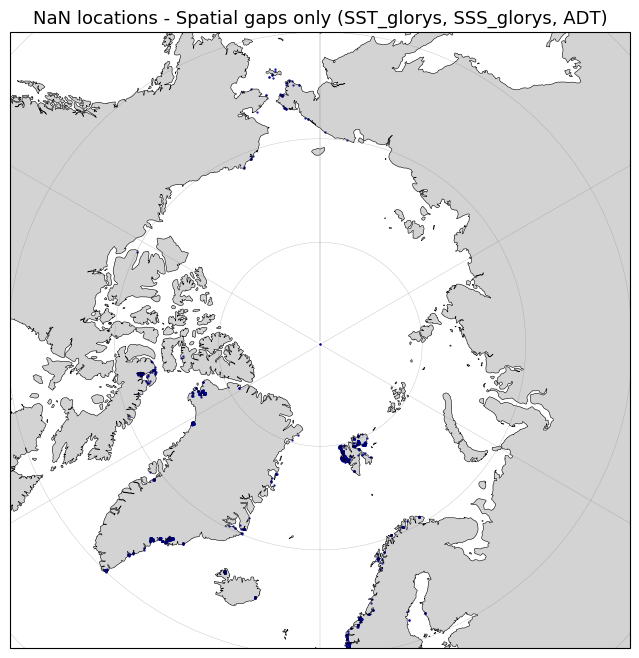

In [40]:
# Create figure with Arctic projection
fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection=ccrs.NorthPolarStereo())

# Plot profiles with NaN values (spatial gaps only, since time filtering was already done)
x_vals = ds_insitu['LONGITUDE'].values[nan_mask.values]
y_vals = ds_insitu['LATITUDE'].values[nan_mask.values]

# Limit to Arctic region
ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.COASTLINE, linewidth=0.4)
ax.gridlines(draw_labels=False, linewidth=0.3, color='gray', alpha=0.5)

# Scatter colored by year 
sc = ax.scatter(
    x_vals,
    y_vals,
    #c=ds_insitu['TEMP'].isel(depth=0).values,
    s=0.5,
    c='darkblue', 
    alpha=0.8,
    transform=ccrs.PlateCarree()
)

plt.title("NaN locations - Spatial gaps only (SST_glorys, SSS_glorys, ADT)", fontsize=13)
plt.show()
#plt.savefig("Insitu_profile_salinity.png", dpi=350)

---
---

In [42]:
# Rebuild ds_insitu dataset using the mask ~nan_mask_values
# Create new dataset with filtered profiles
nan_mask_values = nan_mask.values
clean_profiles = ~nan_mask_values

# Create new coordinates
new_profile_coord = np.arange(np.sum(clean_profiles))
depth_coord = ds_insitu.coords['depth']

# Initialize the clean dataset with coordinates
ds_clean = xr.Dataset(
    coords={
        'profile': new_profile_coord,
        'depth': depth_coord
    }
)

# Copy global attributes
ds_clean.attrs = dict(ds_insitu.attrs)

# Loop through all data variables and apply the mask
for var_name, var_data in ds_insitu.data_vars.items():
    if 'profile' in var_data.dims:
        # Apply mask to profile dimension
        filtered_values = var_data.values[clean_profiles]
        
        # Create new DataArray with filtered data
        ds_clean[var_name] = xr.DataArray(
            filtered_values,
            dims=var_data.dims,
            coords={dim: ds_clean.coords[dim] if dim in ds_clean.coords else var_data.coords[dim] 
                   for dim in var_data.dims},
            attrs=dict(var_data.attrs)
        )
    else:
        # Variable doesn't have profile dimension, copy as is
        ds_clean[var_name] = var_data.copy(deep=True)
        print(f"Copied variable without profile dimension: {var_name}")

print(f"Original profiles: {len(ds_insitu.profile)}")
print(f"Clean profiles (no NaNs): {len(ds_clean.profile)}")
print(f"Profiles removed: {len(ds_insitu.profile) - len(ds_clean.profile)}")

ds_clean

Original profiles: 187276
Clean profiles (no NaNs): 183565
Profiles removed: 3711


<xarray.Dataset> Size: 918MB
Dimensions:            (depth: 102, profile: 183565)
Coordinates:
  * depth              (depth) float64 816B 0.0 5.0 10.0 ... 5.4e+03 5.5e+03
  * profile            (profile) int64 1MB 0 1 2 3 ... 183562 183563 183564
Data variables: (12/19)
    LATITUDE           (profile) float64 1MB 78.37 77.89 78.43 ... 63.93 70.64
    LONGITUDE          (profile) float64 1MB -149.9 11.29 ... -0.2012 -12.01
    TIME               (profile) datetime64[ns] 1MB 2011-01-01T00:00:00.05999...
    TEMP               (profile, depth) float64 150MB -1.476 -1.476 ... nan nan
    PSAL               (profile, depth) float64 150MB 27.11 27.11 ... nan nan
    PRES               (profile, depth) float64 150MB 0.0 0.0 10.11 ... 0.0 0.0
    ...                 ...
    Y_EASE             (profile) float64 1MB 1.122e+06 -1.324e+06 ... -2.104e+06
    SST_glorys         (profile) float64 1MB -1.596 -1.419 ... 7.092 1.584
    SSS_glorys         (profile) float64 1MB 29.97 34.56 34.5 ... 35.04 34.82
    ADT                (profile) float64 1MB 0.3588 -0.1985 ... -0.1731 -0.3381
    SST                (profile) float64 1MB -1.46 -1.04 -1.41 ... 6.93 2.05
    SSS                (profile) float64 1MB 30.04 34.64 34.57 ... 34.8 34.77
Attributes:
    title:                  An Arctic Ocean Thermohaline Dataset
    institution:            Key Laboratory of Marine Hazard Forecasting, Mini...
    platform_type:          XX
    doi:                    10.1038/s41597-025-05855-3
    glorys_offset_pattern:  A tolerance window of 5 by 5 indices centered at ...

In [43]:
print(f"insitu dataset size: {ds_insitu.nbytes / 1e9:.2f} GB")

insitu dataset size: 0.94 GB


-----------------------
-----------------------
PLOTS

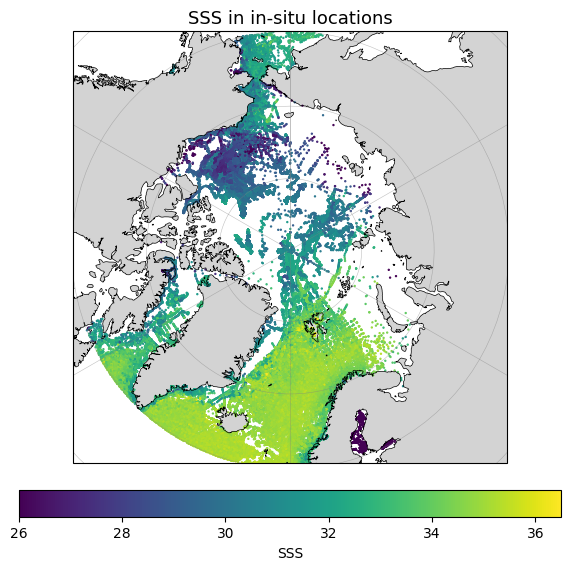

In [44]:
# Extract lat/lon
lats = ds_clean['LATITUDE'].values
lons = ds_clean['LONGITUDE'].values

# Create figure and Arctic projection
fig = plt.figure(figsize=(7, 7))
ax = plt.axes(projection=ccrs.NorthPolarStereo())

# Set extent: Northern Hemisphere only
ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())

# Add features
ax.add_feature(
cfeature.LAND
, facecolor='lightgray')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.gridlines(draw_labels=False, linewidth=0.4, color='gray', alpha=0.5)


# Scatter colored by year 
sc = ax.scatter(
    lons, lats,
    c = ds_clean.SSS.values,
    s = 0.5,
    cmap ='viridis', 
    transform=ccrs.PlateCarree(), vmin=26, vmax=36.5  
)

cbar = plt.colorbar(sc, ax=ax, orientation='horizontal', pad=0.05)
cbar.set_label('SSS')
plt.title("SSS in in-situ locations", fontsize=13)
#plt.savefig(f'fresh_data/{maxdepth}m_in_situ_locations_sss.png', dpi=350)
plt.show()

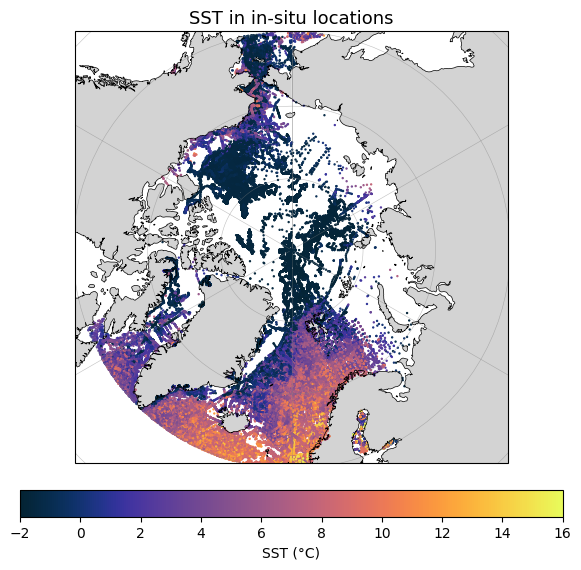

In [45]:
# Extract lat/lon
lats = ds_insitu['LATITUDE'].values
lons = ds_insitu['LONGITUDE'].values

# Create figure and Arctic projection
fig = plt.figure(figsize=(7, 7))
ax = plt.axes(projection=ccrs.NorthPolarStereo())

# Set extent: Northern Hemisphere only
ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())

# Add features
ax.add_feature(
cfeature.LAND
, facecolor='lightgray')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.gridlines(draw_labels=False, linewidth=0.4, color='gray', alpha=0.5)


# Scatter colored by year 
sc = ax.scatter(
    lons, lats,
    c = ds_insitu.SST.values,
    s = 0.5,
    cmap =cm.thermal, 
    transform=ccrs.PlateCarree(),
    vmin=-2, vmax=16 
)

cbar = plt.colorbar(sc, ax=ax, orientation='horizontal', pad=0.05)
cbar.set_label('SST (°C)')
plt.title("SST in in-situ locations", fontsize=13)
#plt.savefig(f'fresh_data/{maxdepth}m_in_situ_locations_sst.png', dpi=350)
plt.show()

LAST CHECK FOR NANS BEFORE SAVING

In [46]:
# Check for NaN values in ds_clean dataset
sss_nans_clean = ds_clean['SSS'].isnull().sum().compute()
sst_nans_clean = ds_clean['SST'].isnull().sum().compute()

print(f"NaN values in ds_clean:")
print(f"SSS_glorys: {sss_nans_clean.item()}")
print(f"SST_glorys: {sst_nans_clean.item()}")
print(f"Total NaNs: {(sss_nans_clean + sst_nans_clean).item()}")

NaN values in ds_clean:
SSS_glorys: 0
SST_glorys: 0
Total NaNs: 0


In [47]:
ds_clean

<xarray.Dataset> Size: 918MB
Dimensions:            (depth: 102, profile: 183565)
Coordinates:
  * depth              (depth) float64 816B 0.0 5.0 10.0 ... 5.4e+03 5.5e+03
  * profile            (profile) int64 1MB 0 1 2 3 ... 183562 183563 183564
Data variables: (12/19)
    LATITUDE           (profile) float64 1MB 78.37 77.89 78.43 ... 63.93 70.64
    LONGITUDE          (profile) float64 1MB -149.9 11.29 ... -0.2012 -12.01
    TIME               (profile) datetime64[ns] 1MB 2011-01-01T00:00:00.05999...
    TEMP               (profile, depth) float64 150MB -1.476 -1.476 ... nan nan
    PSAL               (profile, depth) float64 150MB 27.11 27.11 ... nan nan
    PRES               (profile, depth) float64 150MB 0.0 0.0 10.11 ... 0.0 0.0
    ...                 ...
    Y_EASE             (profile) float64 1MB 1.122e+06 -1.324e+06 ... -2.104e+06
    SST_glorys         (profile) float64 1MB -1.596 -1.419 ... 7.092 1.584
    SSS_glorys         (profile) float64 1MB 29.97 34.56 34.5 ... 35.04 34.82
    ADT                (profile) float64 1MB 0.3588 -0.1985 ... -0.1731 -0.3381
    SST                (profile) float64 1MB -1.46 -1.04 -1.41 ... 6.93 2.05
    SSS                (profile) float64 1MB 30.04 34.64 34.57 ... 34.8 34.77
Attributes:
    title:                  An Arctic Ocean Thermohaline Dataset
    institution:            Key Laboratory of Marine Hazard Forecasting, Mini...
    platform_type:          XX
    doi:                    10.1038/s41597-025-05855-3
    glorys_offset_pattern:  A tolerance window of 5 by 5 indices centered at ...

SAVE THE DATASET

In [50]:
print(f"Saving final dataset to {out_path}...")
ds_clean.to_netcdf(out_path)
print(f"Dataset saved successfully! File saved at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Saving final dataset to ../data_for_lstm/var_depths_data_for_LSTM_A2.nc...
Dataset saved successfully! File saved at: 2026-04-11 16:49:40
